![logo](https://www.python.org/static/community_logos/python-powered-h-70x91.png)
# **<font color="DarkBlue">Estadística Inferencial con Python - Parte 1**
### *Conceptos fundamentales, Distribuciones Muestrales, Teorema del Límite Central, Intervalos de Confianza y Pruebas de Hipótesis de una Muestra*


In [12]:
##warnings
import warnings
warnings.filterwarnings('ignore')

## **<font color="DarkBlue">Librerías**
Para realizar análisis de estadística inferencial, utilizaremos un conjunto de herramientas estándar para la manipulación de datos, el cálculo de distribuciones y la visualización interactiva y estática.


In [10]:
# Manipulación de datos y computación científica
import pandas as pd
import numpy as np
import scipy.stats as stats

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configuración para que los gráficos estáticos se vean modernos
sns.set_theme(style="whitegrid")  ##Aplica un tema visual estético a los gráficos. El estilo "whitegrid" coloca un fondo blanco limpio e incorpora una cuadrícula gris de fondo. Esta cuadrícula facilita mucho la lectura y el cruce de los datos con los ejes $X$ e $Y$.
plt.rcParams['figure.figsize'] = [10, 6]  ##Modifica el tamaño por defecto de todas las figuras que vayas a crear. Los valores representan [ancho, alto] en pulgadas. En este caso, establece proporciones rectangulares y amplias (10 pulgadas de ancho por 6 de alto), ideales para pantalla
plt.rcParams['figure.dpi'] = 100 ##Establece la resolución del gráfico en Puntos Por Pulgada (DPI - Dots Per Inch). Un valor de 100 genera una imagen nítida para visualizar en pantalla sin consumir demasiada memoria. Si necesitas exportar el gráfico para impresión, podrías subir este valor a 300.


## **<font color="DarkBlue">1. Teorema del Límite Central (TLC)**
El **Teorema del Límite Central (TLC)** es uno de los pilares de la estadística inferencial. Establece que, si tomamos muestras aleatorias repetidas de tamaño $n$ de cualquier población (sin importar su distribución de origen), la distribución de las **medias muestrales** se aproximará a una **Distribución Normal** a medida que el tamaño de la muestra ($n$) aumente.

### **Propiedades Clave:**
1. **Media de las medias muestrales:** $\mu_{\bar{x}} = \mu$ (la media de la distribución de medias es igual a la media de la población).
2. **Error Estándar (Desviación estándar de las medias):** $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$ (la variabilidad de las medias disminuye al aumentar el tamaño muestral).
3. **Normalidad:** Si $n \ge 30$, la distribución de las medias muestrales es aproximadamente normal, incluso si la población original es fuertemente sesgada.

### **Simulación Práctica en Python**
Vamos a generar una población con una distribución **Exponencial** (totalmente asimétrica y no normal) y luego extraeremos muestras aleatorias de tamaños $n=2$, $n=10$, $n=30$ y $n=100$ para observar cómo cambia la distribución de las medias muestrales.


### Teorema del Límite Central (TLC): Resumen Analítico

| Concepto / Componente | Definición Teórica | Fórmula / Condición | Interpretación Práctica |
| :--- | :--- | :--- | :--- |
| <span style="color:#1565C0">**Definición General (TLC)**</span> | La distribución de las medias de muestras aleatorias tiende a una distribución normal, sin importar la distribución original. | $n \to \infty \Rightarrow \bar{X} \sim N(\mu, \frac{\sigma}{\sqrt{n}})$ | Permite usar estadística paramétrica en datos no normales si la muestra es suficientemente grande. |
| <span style="color:#2E7D32">**Media de las Medias Muestrales**</span> | La media de todas las medias muestrales posibles es igual a la media real poblacional. | $\mu_{\bar{x}} = \mu$ | El promedio de tus muestras es un estimador insesgado; "apunta" directamente al valor real. |
| <span style="color:#E65100">**Error Estándar**</span> | Desviación estándar de la distribución de medias. Mide cuánto varían respecto a la media real. | $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$ | A mayor tamaño de muestra ($n$), menor error. Las estimaciones se vuelven mucho más precisas. |
| <span style="color:#6A1B9A">**Condición de Normalidad**</span> | Regla empírica para asumir que la aproximación a la curva normal es suficientemente buena. | $n \ge 30$ | Con 30 o más datos por muestra, se asume normalidad en las medias, aunque la población sea fuertemente sesgada. |
| <span style="color:#C62828">**Simulación Práctica**</span> | Extraer muestras de una población asimétrica (ej. exponencial) y graficar sus promedios. | $n \in \{2, 10, 30, 100\}$ | Con $n=2$ sigue asimétrica. Con $n=10$ toma forma de campana. Con $n \ge 30$ es una campana de Gauss perfecta. |

> **Nota Teórica:** El poder del TLC radica en que nos permite inferir características de toda una población utilizando solo la media y la desviación estándar de una muestra, lo que es la base de las pruebas de hipótesis y los intervalos de confianza.

Media Poblacional Real (\mu): 1.9919
Desviación Estándar Poblacional Real (\sigma): 1.9859


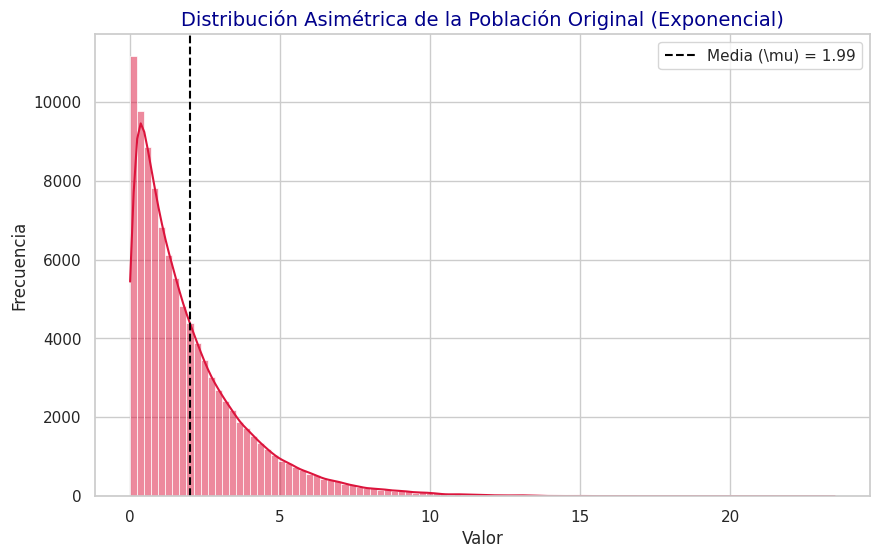

In [13]:
# Definimos una semilla para reproducibilidad
np.random.seed(42)

# 1. Creamos una población con distribución Exponencial (totalmente sesgada)
poblacion = np.random.exponential(scale=2, size=100000)
media_poblacional = np.mean(poblacion)
desv_poblacional = np.std(poblacion)

print(f"Media Poblacional Real (\mu): {media_poblacional:.4f}")
print(f"Desviación Estándar Poblacional Real (\sigma): {desv_poblacional:.4f}")

# Graficamos la población original
sns.histplot(poblacion, kde=True, color="crimson", bins=100)
plt.axvline(media_poblacional, color="black", linestyle="--", label=f"Media (\mu) = {media_poblacional:.2f}")
plt.title("Distribución Asimétrica de la Población Original (Exponencial)", fontsize=14, color="DarkBlue")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


### Análisis Explicativo: Población Original (Distribución Exponencial)

| Componente del Gráfico | Interpretación Visual | Rol Teórico (Contexto TLC) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Forma de la Distribución**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Asimétrica Positiva</span><br>• Totalmente sesgada a la derecha.<br>• No tiene forma de campana (Normal). | • Es el ejemplo perfecto de una población **no normal** para poner a prueba la magia del TLC. |
| <span style="color:#2E7D32">**Concentración de Datos**</span> | • El pico más alto está pegado al cero.<br>• Cae drásticamente (como un tobogán). | • Indica que la inmensa mayoría de las observaciones individuales toman valores muy bajos. |
| <span style="color:#E65100">**Línea Punteada Negra ($\mu$)**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Media Real $\approx 1.99$</span><br>• Está desplazada a la derecha del pico. | • Representa la verdadera Media Poblacional.<br>• Es "arrastrada" hacia la derecha por los pocos valores extremos altos. |
| <span style="color:#6A1B9A">**Cola Derecha (Eje X: 10 a 20)**</span> | • Se extiende hacia valores muy altos.<br>• Las barras allí son casi invisibles. | • Representa eventos raros o atípicos de la población original. |
| <span style="color:#C62828">**El Reto para el TLC**</span> | Son los datos "crudos" y caóticos antes de someterlos a cálculo. | • A pesar de esta forma de "tobogán", el TLC afirma que si sacamos muestras de aquí, **sus promedios** formarán una campana simétrica. |

> **Nota Teórica:** En una distribución exponencial como esta, la media y la desviación estándar poblacional suelen ser prácticamente iguales (como se lee en el texto de tu imagen: $\mu = 1.9919$ y $\sigma = 1.9859$). Observar esta asimetría inicial es clave para valorar cómo la distribución de las medias muestrales corrige este sesgo a medida que el tamaño de la muestra ($n$) crece.

Ahora, realizaremos la simulación tomando **10,000 muestras aleatorias** para cada tamaño muestral ($n$) y calculando su media muestral.


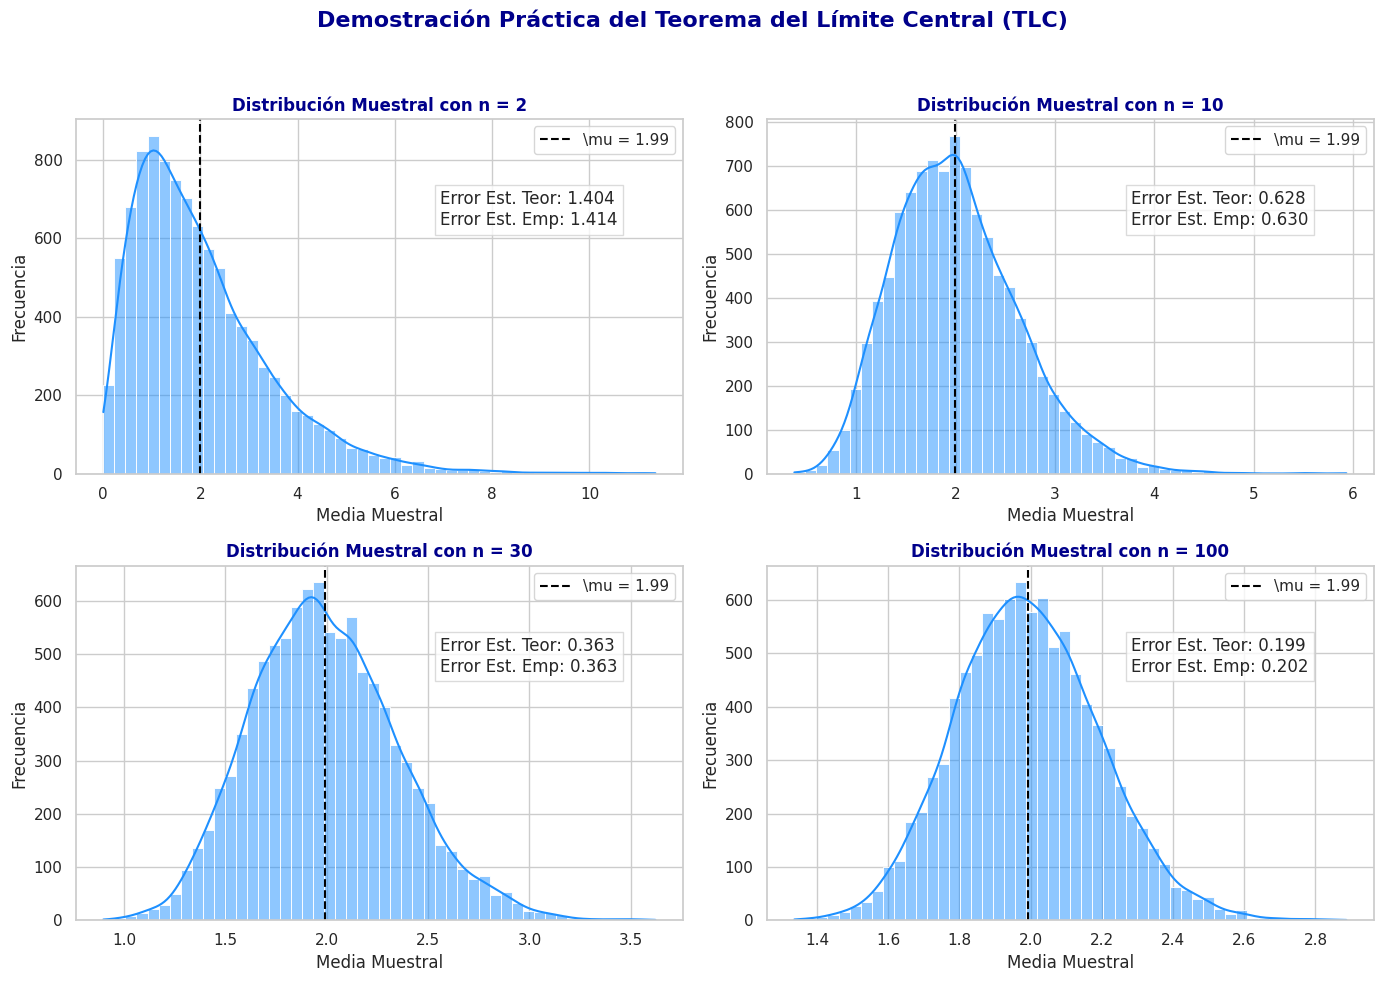

In [14]:
def simular_medias_muestrales(poblacion, n, num_muestras=10000):
    medias = []
    for _ in range(num_muestras):
        muestra = np.random.choice(poblacion, size=n, replace=True)
        medias.append(np.mean(muestra))
    return np.array(medias)

# Simulamos para diferentes tamaños de muestra
tamanos_n = [2, 10, 30, 100]
resultados = {n: simular_medias_muestrales(poblacion, n) for n in tamanos_n}

# Graficamos los resultados en subplots para comparar
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
axes = axes.flatten()

for idx, n in enumerate(tamanos_n):
    medias_n = resultados[n]
    media_estimada = np.mean(medias_n)
    error_estandar_estimado = np.std(medias_n)
    error_estandar_teorico = desv_poblacional / np.sqrt(n)

    sns.histplot(medias_n, kde=True, ax=axes[idx], color="dodgerblue", bins=50)
    axes[idx].axvline(media_poblacional, color="black", linestyle="--", label=f"\mu = {media_poblacional:.2f}")
    axes[idx].set_title(f"Distribución Muestral con n = {n}", fontsize=12, fontweight='bold', color="DarkBlue")
    axes[idx].set_xlabel("Media Muestral")
    axes[idx].set_ylabel("Frecuencia")

    # Añadimos un texto informativo sobre el error estándar
    axes[idx].text(0.6, 0.7,
                   f"Error Est. Teor: {error_estandar_teorico:.3f}\nError Est. Emp: {error_estandar_estimado:.3f}",
                   transform=axes[idx].transAxes,
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))
    axes[idx].legend()

plt.suptitle("Demostración Práctica del Teorema del Límite Central (TLC)", fontsize=16, fontweight='bold', color="DarkBlue")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### **Conclusiones del TLC:**
- **Forma de la Distribución:** Con $n=2$, la distribución muestral sigue siendo asimétrica a la derecha (similar a la original). Conforme $n$ aumenta a $30$ y $100$, la distribución de las medias muestrales se vuelve perfectamente simétrica y en forma de campana (normal).
- **Varianza:** Al aumentar $n$, el rango de las medias muestrales posibles se estrecha significativamente; las medias están cada vez más concentradas en torno a la media poblacional real $\mu$.
- **Error Estándar:** El error estándar empírico (desviación estándar de nuestras medias muestrales obtenidas) coincide casi de manera idéntica con el error estándar teórico ($\sigma / \sqrt{n}$).


### Análisis: Distribución Muestral ($n = 2$)

| Característica | Observación Visual | Interpretación Estadística |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Forma de la Distribución**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Asimétrica (Sesgada)</span> | Aún conserva la forma de "tobogán" de la población exponencial original. |
| <span style="color:#2E7D32">**Dispersión (Eje X)**</span> | Muy amplia (de 0 a 10). | Los promedios calculados varían enormemente entre una muestra y otra. |
| <span style="color:#E65100">**Error Estándar**</span> | **Alto ($\approx 1.40$)** | El error de estimación es demasiado grande. |
| <span style="color:#6A1B9A">**Conclusión del TLC**</span> | **Insuficiente.** | Un tamaño de $n=2$ no es suficiente para que el Teorema del Límite Central neutralice la asimetría original. |

### Análisis: Distribución Muestral ($n = 10$)

| Característica | Observación Visual | Interpretación Estadística |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Forma de la Distribución**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">En Transición</span> | Empieza a formarse una campana, pero la cola derecha sigue siendo un poco más larga. |
| <span style="color:#2E7D32">**Dispersión (Eje X)**</span> | Se reduce a la mitad (de 1 a 6). | Los datos comienzan a "empujarse" hacia el centro. |
| <span style="color:#E65100">**Error Estándar**</span> | **Medio ($\approx 0.63$)** | La variabilidad cae significativamente respecto a $n=2$. |
| <span style="color:#6A1B9A">**Conclusión del TLC**</span> | **Fase Intermedia.** | El efecto del teorema es visible, pero estadísticamente aún no es seguro asumir normalidad plena. |

### Análisis: Distribución Muestral ($n = 30$)

| Característica | Observación Visual | Interpretación Estadística |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Forma de la Distribución**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Campana Simétrica</span> | Adiós al sesgo; la forma de distribución Normal ya es evidente. |
| <span style="color:#2E7D32">**Dispersión (Eje X)**</span> | Muy concentrada (de 1.0 a 3.5). | Las medias muestrales ya no se alejan mucho del valor central. |
| <span style="color:#E65100">**Error Estándar**</span> | **Bajo ($\approx 0.36$)** | Alta confiabilidad en que la media muestral está cerca de la real. |
| <span style="color:#6A1B9A">**Conclusión del TLC**</span> | **Punto de Inflexión.** | Se cumple la regla empírica universal ($n \ge 30$). A partir de aquí, podemos usar pruebas paramétricas. |

### Análisis: Distribución Muestral ($n = 100$)

| Característica | Observación Visual | Interpretación Estadística |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Forma de la Distribución**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">Campana Perfecta</span> | Curva Gaussiana ideal, más estrecha y alta (mayor curtosis). |
| <span style="color:#2E7D32">**Dispersión (Eje X)**</span> | Extremadamente estrecha (1.4 a 2.8). | Casi todas las muestras arrojan un promedio pegado al $\mu = 1.99$. |
| <span style="color:#E65100">**Error Estándar**</span> | **Mínimo ($\approx 0.20$)** | La variabilidad es insignificante. |
| <span style="color:#6A1B9A">**Conclusión del TLC**</span> | **Precisión Máxima.** | Demostración final del teorema: la incertidumbre inferencial se reduce drásticamente al aumentar los datos poblacionales muestreados. |

## **<font color="DarkBlue">2. Estimación por Intervalos de Confianza (IC)**
En lugar de dar un único valor estimado para un parámetro poblacional (estimación puntual), la **estimación por intervalos** proporciona un rango de valores probables que contiene al parámetro con un determinado nivel de confianza ($1 - \alpha$).

### **Caso 1: Intervalo de Confianza para la Media con $\sigma$ poblacional conocida (Distribución Z)**
Se utiliza cuando conocemos la desviación estándar poblacional $\sigma$. La fórmula es:
$$IC = \bar{x} \pm z_{\alpha/2} \left( \frac{\sigma}{\sqrt{n}} \right)$$
Donde $z_{\alpha/2}$ es el valor crítico de la distribución normal estándar.

**Ejemplo Práctico:** Supongamos que conocemos la desviación estándar poblacional del coeficiente intelectual (IQ), la cual es $\sigma = 15$. Tomamos una muestra aleatoria de $n = 50$ personas y obtenemos una media muestral $\bar{x} = 104$. Calcularemos un intervalo de confianza del **95%**.


### Estimación por Intervalos de Confianza (Distribución Z): Análisis Analítico

| Componente / Concepto | Símbolo / Fórmula | Significado Teórico | Aplicación al Ejemplo (IQ) |
| :--- | :--- | :--- | :--- |
| <span style="color:#1565C0">**Estimación por Intervalo**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">$IC = [\text{Límite Inf.}, \text{Límite Sup.}]$</span> | Rango de valores dentro del cual es muy probable que se encuentre el verdadero parámetro poblacional (que desconocemos). | En lugar de decir "el IQ promedio mundial es exactamente 104", daremos un margen seguro. |
| <span style="color:#2E7D32">**Estimación Puntual (Centro)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">$\bar{x}$</span> | Es la media de tu muestra. Es el "ancla" o centro exacto de tu intervalo de confianza. | $\bar{x} = 104$ |
| <span style="color:#E65100">**Error Estándar (SE)**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">$\frac{\sigma}{\sqrt{n}}$</span> | Mide cuánta variabilidad hay en las estimaciones. Cae a medida que la muestra ($n$) crece. | $\frac{15}{\sqrt{50}} \approx 2.12$ |
| <span style="color:#6A1B9A">**Valor Crítico**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">$z_{\alpha/2}$</span> | Es el multiplicador basado en tu Nivel de Confianza (ej. 95%). Viene de la tabla Normal Estándar. | Para 95% de confianza, el valor Z es siempre **$1.96$**. |
| <span style="color:#C62828">**Margen de Error (ME)**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px

In [4]:
import scipy.stats as stats

n = 50
x_barra = 104.0
sigma = 15.0
confianza = 0.95

# Calculamos el intervalo usando scipy.stats.norm
ic_z = stats.norm.interval(confidence=confianza, loc=x_barra, scale=sigma / np.sqrt(n))

print(f"Intervalo de confianza del 95% para la media (Z): {ic_z}")
print(f"Margen de error: {stats.norm.ppf(0.975) * (sigma / np.sqrt(n)):.4f}")
print(f"Interpretación: Tenemos un 95% de seguridad de que la media real del IQ poblacional está entre {ic_z[0]:.2f} y {ic_z[1]:.2f}.")


Intervalo de confianza del 95% para la media (Z): (np.float64(99.84228852695097), np.float64(108.15771147304903))
Margen de error: 4.1577
Interpretación: Tenemos un 95% de seguridad de que la media real del IQ poblacional está entre 99.84 y 108.16.


### **Caso 2: Intervalo de Confianza para la Media con $\sigma$ desconocida (Distribución t de Student)**
En la práctica real, casi nunca conocemos la desviación estándar poblacional $\sigma$. En su lugar, utilizamos la desviación estándar de la muestra ($s$) y la **distribución t de Student** con $n-1$ grados de libertad ($gl$). La fórmula es:
$$IC = \bar{x} \pm t_{\alpha/2, n-1} \left( \frac{s}{\sqrt{n}} \right)$$

**Ejemplo Práctico:** Analicemos una muestra sintética de gastos de servicios médicos (charges) de 40 pacientes de un hospital y calculemos el intervalo de confianza al 95%.


### Estimación por Intervalos (t de Student): Cuadro Optimizado

| Componente | Fórmula | Significado Teórico | Aplicación al Ejemplo |
| :--- | :--- | :--- | :--- |
| <span style="color:#1565C0">**El Problema Real**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">$\sigma$ desconocida</span> | • Se ignora la varianza total.<br>• Exige usar "t" en vez de "Z". | • Datos de solo 40 pacientes.<br>• No de toda la población. |
| <span style="color:#2E7D32">**Estimación Puntual**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">$\bar{x}$</span> | • Promedio exacto de tu muestra. | • Asumimos: $\bar{x} = \$15,000$ |
| <span style="color:#E65100">**Desviación Muestral**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">$s$</span> | • Desviación estándar muestral.<br>• Reemplaza a la $\sigma$ poblacional. | • Asumimos: $s = \$5,000$ |
| <span style="color:#6A1B9A">**Grados de Libertad**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">$gl = n - 1$</span> | • Ajusta la forma de la curva t. | • $gl = 40 - 1 = \mathbf{39}$ |
| <span style="color:#00695C">**Error Estándar (SE)**</span> | <span style="background-color:#E0F2F1; color:#004D40; padding:2px 5px; border-radius:3px;">$\frac{s}{\sqrt{n}}$</span> | • Variabilidad estimada de medias. | • $\frac{5000}{\sqrt{40}} \approx \mathbf{\$790.57}$ |
| <span style="color:#C62828">**Valor Crítico (t)**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">$t_{\alpha/2, n-1}$</span> | • Multiplicador de la tabla T.<br>• Más conservador que la tabla Z. | • Nivel 95% y 39 gl:<br>• $t \approx \mathbf{2.023}$ |
| <span style="color:#4E342E">**Margen de Error**</span>| <span style="background-color:#EFEBE9; color:#3E2723; padding:2px 5px; border-radius:3px;">$t \times SE$</span> | • "Colchón" de incertidumbre final. | • $2.023 \times 790.57 \approx \mathbf{\$1,599.32}$ |

> **Resultado Práctico (Gastos Médicos):** > Promedio muestral $\pm$ Margen de Error: $\$15,000 \pm \$1,599.32$.
> **Intervalo de Confianza al 95% = $[\$13,400.68, \ \$16,599.32]$**
> *Interpretación final:* "Tenemos un 95% de confianza en que el verdadero gasto promedio de **todos los pacientes** del hospital está entre \$13,400.68 y \$16,599.32."

In [5]:
np.random.seed(101)
# Simulamos gastos médicos con sesgo
gastos_pacientes = np.random.lognormal(mean=8.5, sigma=0.5, size=40)

n_t = len(gastos_pacientes)
x_barra_t = np.mean(gastos_pacientes)
s_t = np.std(gastos_pacientes, ddof=1) # ddof=1 para obtener la desviación estándar muestral
gl = n_t - 1

# Calculamos el intervalo usando scipy.stats.t
ic_t = stats.t.interval(confidence=0.95, df=gl, loc=x_barra_t, scale=s_t / np.sqrt(n_t))

print(f"Datos de la muestra: n={n_t}, Media muestral={x_barra_t:.2f}, Desv. estándar={s_t:.2f}")
print(f"Intervalo de confianza del 95% (t-Student): [{ic_t[0]:.2f}, {ic_t[1]:.2f}]")


Datos de la muestra: n=40, Media muestral=6603.93, Desv. estándar=3913.95
Intervalo de confianza del 95% (t-Student): [5352.19, 7855.67]


### **Caso 3: Intervalo de Confianza para una Proporción Poblacional ($p$)**
Para variables cualitativas (por ejemplo, el porcentaje de clientes satisfechos o intención de voto). La fórmula basada en la aproximación normal es:
$$IC = \hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$
Donde $\hat{p}$ es la proporción muestral.

**Ejemplo Práctico:** En una encuesta a $n = 500$ usuarios de una app, $350$ indicaron estar totalmente satisfechos ($\hat{p} = 350/500 = 0.70$). Calcularemos un intervalo de confianza al **99%**.


### Estimación por Intervalos (Proporción Poblacional): Cuadro Optimizado

| Componente | Fórmula / Símbolo | Significado Teórico | Aplicación al Ejemplo (Encuesta App) |
| :--- | :--- | :--- | :--- |
| <span style="color:#1565C0">**Caso de Uso**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Variables Cualitativas</span> | • Para medir porcentajes, tasas o intenciones.<br>• Ej: Respuestas de "Sí/No", "Satisfecho/Insatisfecho". | • Queremos conocer el % real de satisfacción de **todos** los usuarios de la app. |
| <span style="color:#2E7D32">**Proporción Muestral**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">$\hat{p} = \frac{x}{n}$</span> | • El porcentaje de "éxitos" (lo que buscamos medir) calculado solo en tu muestra. | • $\hat{p} = \frac{350}{500} = \mathbf{0.70}$ ($70\%$) |
| <span style="color:#E65100">**Complemento**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">$(1 - \hat{p})$ o $\hat{q}$</span> | • El porcentaje de "fracasos" o la otra cara de la moneda poblacional. | • $1 - 0.70 = \mathbf{0.30}$ ($30\%$) |
| <span style="color:#00695C">**Error Estándar (SE)**</span> | <span style="background-color:#E0F2F1; color:#004D40; padding:2px 5px; border-radius:3px;">$\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$</span> | • La variabilidad esperada de esta proporción si tomáramos muchas muestras distintas. | • $\sqrt{\frac{0.70 \times 0.30}{500}} \approx \mathbf{0.0205}$ |
| <span style="color:#C62828">**Valor Crítico (Z)**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">$z_{\alpha/2}$</span> | • Para proporciones (si $n$ es grande), siempre usamos la distribución Normal (Z). | • Nivel 99% de confianza:<br>• $z \approx \mathbf{2.576}$ |
| <span style="color:#4E342E">**Margen de Error**</span>| <span style="background-color:#EFEBE9; color:#3E2723; padding:2px 5px; border-radius:3px;">$z \times SE$</span> | • El margen en porcentaje sumado y restado a tu estimación original. | • $2.576 \times 0.0205 \approx \mathbf{0.0528}$ ($5.28\%$) |

> **Resultado Práctico (Satisfacción de la App):** > Proporción muestral $\pm$ Margen de Error: $0.70 \pm 0.0528$.
> **Intervalo de Confianza al 99% = $[0.6472, \ 0.7528]$ (o sea, del $64.72\%$ al $75.28\%$)**
> *Interpretación final:* "Tenemos un 99% de confianza en que el porcentaje real de usuarios totalmente satisfechos en **toda la base de usuarios de la app** se encuentra entre el $64.72\%$ y el $75.28\%$."

In [6]:
n_prop = 500
exitos = 350
p_hat = exitos / n_prop
confianza_prop = 0.99

# Error estándar de la proporción
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_prop)

# Intervalo
ic_prop = stats.norm.interval(confidence=confianza_prop, loc=p_hat, scale=se_prop)

print(f"Proporción muestral: {p_hat * 100:.2f}%")
print(f"Intervalo de confianza al 99% para la proporción poblacional: [{ic_prop[0]*100:.2f}%, {ic_prop[1]*100:.2f}%]")


Proporción muestral: 70.00%
Intervalo de confianza al 99% para la proporción poblacional: [64.72%, 75.28%]


### **Simulación Gráfica Interactiva: ¿Qué significa realmente un "Nivel de Confianza del 95%"?**
El nivel de confianza del 95% significa que si tomamos 100 muestras independientes de la misma población y calculamos un intervalo de confianza para cada una, **aproximadamente 95 de ellos contendrán el verdadero parámetro poblacional** y unos 5 fallarán.

Vamos a simular la extracción de 50 muestras de tamaño $n=30$ de una población con media $\mu = 100$ y graficar los intervalos resultantes en tiempo real con Plotly, marcando en **rojo** aquellos que **no logran capturar** la media real.


### Interpretación Real del Nivel de Confianza: Cuadro Analítico

| Concepto en la Simulación | Definición Teórica | Interpretación Práctica (Simulación de 50 Muestras) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**El Nivel de Confianza (95%)**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Tasa de Éxito del Método</span> | • **Falso:** "Hay 95% de probabilidad de que mi media esté aquí".<br>• **Verdad:** Es la efectividad del método a largo plazo. De 100 intentos, 95 saldrán bien. |
| <span style="color:#2E7D32">**La Media Real ($\mu = 100$)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">El "Blanco" Fijo</span> | • Es el verdadero parámetro de la población.<br>• Es fijo e inmutable. Representa la **línea vertical central** que los intervalos intentan "atrapar". |
| <span style="color:#E65100">**Las Muestras Aleatorias**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Extracción Iterativa</span> | • Tomamos 50 grupos de 30 personas ($n=30$).<br>• Cada grupo tendrá un promedio diferente por puro azar, generando 50 intervalos de confianza distintos. |
| <span style="color:#00695C">**Los Aciertos (Azul/Verde)**</span> | <span style="background-color:#E0F2F1; color:#004D40; padding:2px 5px; border-radius:3px;">Intervalos Exitosos</span> | • Son las líneas horizontales que logran cruzar la línea de la media real (100).<br>• Con un IC del 95%, esperamos que alrededor de **47 o 48** de las 50 líneas lo logren. |
| <span style="color:#C62828">**Los Fallos (Rojos)**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">Error de Muestreo Extremo</span> | • Líneas horizontales que quedan totalmente a la izquierda o derecha del 100.<br>• Son muestras "rebeldes" que tuvieron datos muy atípicos. Esperamos ver **2 o 3 líneas rojas** en cada tirada. |

> **Nota Teórica Crucial:** Una vez calculado un intervalo de confianza específico (por ejemplo, $[92, 105]$), ese intervalo en particular **ya contiene a la media o no la contiene** (probabilidad de 1 o 0). El $95\%$ le pertenece al *procedimiento* de muestreo general que generó la tabla, no a un intervalo individual una vez que ya fue calculado.

In [7]:
np.random.seed(45)
mu_real = 100
sigma_real = 15
n_sim = 30
num_experimentos = 50

medias_sim = []
limite_inf = []
limite_sup = []
contiene_mu = []

for i in range(num_experimentos):
    muestra = np.random.normal(loc=mu_real, scale=sigma_real, size=n_sim)
    m = np.mean(muestra)
    s = np.std(muestra, ddof=1)
    ic = stats.t.interval(confidence=0.95, df=n_sim-1, loc=m, scale=s / np.sqrt(n_sim))

    medias_sim.append(m)
    limite_inf.append(ic[0])
    limite_sup.append(ic[1])
    # Comprobamos si el intervalo contiene al parámetro real (100)
    contiene_mu.append(ic[0] <= mu_real <= ic[1])

# Creamos un DataFrame con los resultados
df_ic = pd.DataFrame({
    'Experimento': list(range(1, num_experimentos + 1)),
    'Media': medias_sim,
    'Límite Inferior': limite_inf,
    'Límite Superior': limite_sup,
    'Contiene_Mu': contiene_mu
})

# Mapeamos el color: Verde si contiene la media real, Rojo si no
df_ic['Color'] = df_ic['Contiene_Mu'].map({True: 'dodgerblue', False: 'crimson'})
df_ic['Resultado'] = df_ic['Contiene_Mu'].map({True: 'Contiene real', False: 'No contiene real'})

# Gráfico interactivo de intervalos de confianza
fig = go.Figure()

# Línea vertical para la media poblacional real
fig.add_shape(
    type="line", x0=mu_real, y0=0, x1=mu_real, y1=num_experimentos + 1,
    line=dict(color="black", width=3, dash="dash")
)

# Añadimos los intervalos
for idx, row in df_ic.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['Límite Inferior'], row['Límite Superior']],
        y=[row['Experimento'], row['Experimento']],
        mode='lines',
        line=dict(color=row['Color'], width=2),
        showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=[row['Media']],
        y=[row['Experimento']],
        mode='markers',
        marker=dict(color=row['Color'], size=6),
        name=row['Resultado'],
        showlegend=(True if idx in [0, 1] else False) # Para no duplicar leyendas
    ))

fig.update_layout(
    title="Simulación de 50 Intervalos de Confianza al 95% respecto a la Media Poblacional Real (\mu = 100)",
    xaxis_title="Valores Estimados",
    yaxis_title="Muestra / Experimento",
    template="gridon",
    height=600
)

fig.show()


<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7798/3067378485.py:65: SyntaxWarning: invalid escape sequence '\m'
  title="Simulación de 50 Intervalos de Confianza al 95% respecto a la Media Poblacional Real (\mu = 100)",


### Análisis Visual: Simulación de Intervalos de Confianza (95%)

| Componente del Gráfico | Observación Visual en tu Gráfico | Interpretación Estadística |
| :--- | :--- | :--- |
| <span style="color:#2E7D32">**Línea Vertical Punteada Negra**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">Fija en $\mu = 100$</span> | • Es la verdadera **Media Poblacional**.<br>• Permanece inmóvil porque es el parámetro real y constante que intentamos "atrapar" con nuestras muestras. |
| <span style="color:#1565C0">**Líneas Horizontales Azules**</span> | • Son la gran mayoría (47 de 50 líneas).<br>• Todas logran cruzar la línea negra. | • Son los **Intervalos Exitosos**.<br>• Estas muestras tuvieron la suerte de capturar la media real dentro de sus respectivos márgenes de error. |
| <span style="color:#6A1B9A">**Puntos sobre las líneas**</span> | • Ubicados en el centro de cada línea.<br>• Ninguno cae exactamente en el mismo lugar (varían entre ~93 y ~107). | • Es la **Estimación Puntual ($\bar{x}$)** de cada muestra.<br>• Demuestra la *variabilidad muestral*: cada vez que mides, obtienes un promedio distinto. |
| <span style="color:#C62828">**Líneas Horizontales Rojas**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">3 líneas que no tocan el 100</span><br>• Están desplazadas muy a la derecha. | • Son los **Intervalos Fallidos**.<br>• Son muestras atípicas (por puro azar) cuyos promedios fueron tan altos que ni siquiera su margen de error alcanzó para tocar el 100 real. |

> **Comprobación Teórica en tu Gráfico:** > Estás usando un Nivel de Confianza del **95%**. Esto significa que esperas un margen de error (o nivel de significancia $\alpha$) del **5%**.
> Si tomaste 50 muestras, matemáticamente esperas que el $5\%$ de ellas fallen: $50 \times 0.05 = \mathbf{2.5}$.
> ¡Tu gráfico muestra exactamente **3 líneas rojas**! Es la prueba empírica perfecta de que la teoría estadística funciona de maravilla en la práctica.

## **<font color="DarkBlue">3. Introducción al Contraste de Hipótesis**
Una **prueba de hipótesis** es una técnica inferencial que nos ayuda a decidir si una afirmación sobre un parámetro poblacional está respaldada por la evidencia empírica de una muestra.

### **Los 5 pasos fundamentales:**
1. **Definir las hipótesis:**
   - **Hipótesis Nula ($H_0$):** Representa el statu quo, la igualdad o no diferencia (ej. $\mu = 800$).
   - **Hipótesis Alternativa ($H_1$):** Es la afirmación de investigación o la sospecha del investigador (ej. $\mu \neq 800$, $\mu < 800$ o $\mu > 800$).
2. **Establecer el nivel de significancia ($\alpha$):** La probabilidad máxima permitida de cometer un **Error Tipo I** (rechazar $H_0$ cuando es verdadera). Típicamente $\alpha = 0.05$ (5%).
3. **Calcular el estadístico de prueba:** Medida del grado de desacuerdo entre los datos muestrales y la hipótesis nula.
4. **Regla de Decisión (p-valor):** Si el p-valor $\le \alpha$, se rechaza $H_0$. Si el p-valor $> \alpha$, no se puede rechazar $H_0$.
5. **Conclusión:** Explicar el resultado en el contexto del problema.

---

### **Prueba t de una muestra (One-Sample t-test)**
Se usa para comparar la media de una muestra con un valor de referencia poblacional conocido.

**Ejemplo de aplicación:** Un fabricante de focos LED asegura que la duración promedio de su producto estrella es de **800 horas**. Un auditor sospecha que la duración real es menor. Toma una muestra de $n = 25$ focos, registra su duración y realiza la prueba estadistica con un $\alpha = 0.05$.


### Aplicación Práctica: Prueba t de una Muestra (Ejemplo Focos LED)

| Paso Metodológico | Aplicación al Caso (Auditoría de Focos) | Explicación del Razonamiento |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**1. Definir Hipótesis**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">**$H_0$:** $\mu = 800$<br>**$H_1$:** $\mu < 800$</span> | • **$H_0$:** El fabricante dice la verdad (duran 800h).<br>• **$H_1$:** La sospecha del auditor (duran menos). Es una prueba de **cola izquierda**. |
| <span style="color:#2E7D32">**2. Nivel Significancia**</span>| <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">$\alpha = 0.05$</span> | • Se asume un riesgo del 5% de acusar injustamente al fabricante de mentir, cuando en realidad sus focos sí duraban 800h. |
| <span style="color:#E65100">**3. Estadístico de Prueba**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">**Prueba t (One-Sample)**</span> | • Usamos la "t de Student" porque comparamos una muestra contra un valor de referencia ($800$), la muestra es pequeña ($n=25$) y no sabemos la desviación $\sigma$ de la fábrica entera. |
| <span style="color:#6A1B9A">**4. Regla de Decisión**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">¿$p$-valor $\le 0.05$?</span> | • Si al correr el código el $p$-valor de la muestra es **menor a 0.05**, la evidencia en contra de la fábrica es lo suficientemente fuerte para rechazar la $H_0$. |
| <span style="color:#C62828">**5. Conclusión Posible**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">Traducción al Negocio</span> | • **Si rechazamos $H_0$:** "Hay evidencia estadística para afirmar que los focos duran menos de 800h. Multa al fabricante".<br>• **Si NO rechazamos $H_0$:** "No hay pruebas suficientes para desmentir al fabricante". |

> **Nota Teórica (¿Por qué de una cola?):** Al auditor no le importa si los focos duran *más* de 800 horas (eso sería bueno para el cliente). Solo le preocupa si duran *menos*. Por eso, toda el área de rechazo ($5\%$) se concentra únicamente en el extremo izquierdo de la campana de distribución.

In [8]:
np.random.seed(50)
# Generamos datos simulados de duración real de focos con una media menor (ej: 782 horas)
duraciones = np.random.normal(loc=782, scale=35, size=25)

# Parámetro a contrastar bajo H0
mu_h0 = 800

# Ejecutamos la prueba t de una muestra
# H0: mu = 800 vs H1: mu < 800 (Prueba de cola izquierda)
t_stat, p_val = stats.ttest_1samp(duraciones, popmean=mu_h0, alternative='less')

print("Resultados de la prueba:")
print(f"Media muestral: {np.mean(duraciones):.2f} horas")
print(f"Desviación estándar muestral: {np.std(duraciones, ddof=1):.2f} horas")
print(f"Estadístico t de prueba: {t_stat:.4f}")
print(f"p-valor: {p_val:.6f}")

alpha = 0.05
if p_val <= alpha:
    print(f"Decisión: Se RECHAZA la Hipótesis Nula (p <= {alpha}).")
    print("Conclusión: Existe evidencia estadísticamente significativa para afirmar que la duración promedio de los focos es inferior a 800 horas.")
else:
    print(f"Decisión: NO SE RECHAZA la Hipótesis Nula (p > {alpha}).")
    print("Conclusión: No hay evidencia suficiente para dudar de la afirmación del fabricante.")


Resultados de la prueba:
Media muestral: 783.93 horas
Desviación estándar muestral: 39.20 horas
Estadístico t de prueba: -2.0498
p-valor: 0.025733
Decisión: Se RECHAZA la Hipótesis Nula (p <= 0.05).
Conclusión: Existe evidencia estadísticamente significativa para afirmar que la duración promedio de los focos es inferior a 800 horas.


### **Visualización Gráfica de la Región de Rechazo y Aceptación**
Para comprender visualmente dónde se sitúa nuestro estadístico de prueba dentro de la distribución teórica bajo la hipótesis nula, graficaremos la densidad de probabilidad t de Student con 24 grados de libertad.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 7 () missing from font(s) DejaVu Sans.



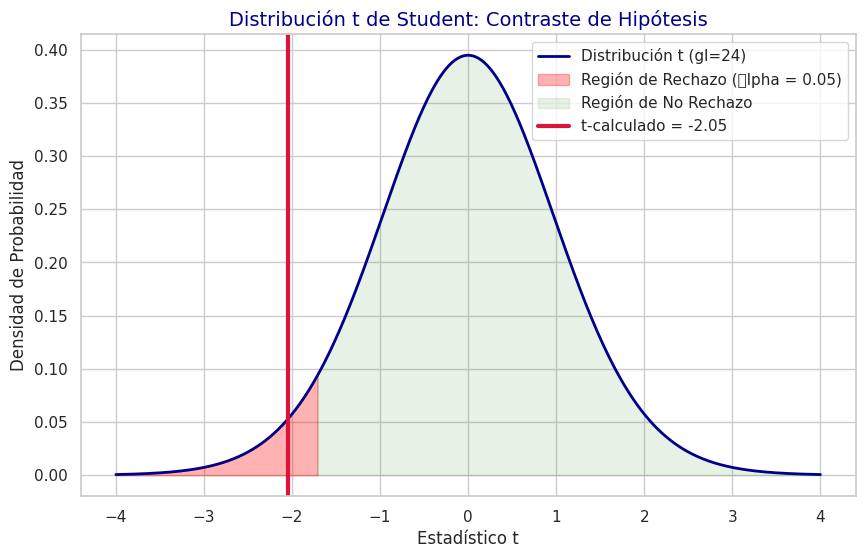

In [9]:
gl_focos = len(duraciones) - 1
x_eje = np.linspace(-4, 4, 500)
y_densidad = stats.t.pdf(x_eje, df=gl_focos)

plt.plot(x_eje, y_densidad, label="Distribución t (gl=24)", color="darkblue", lw=2)

# Valor crítico para una cola izquierda al 95% de confianza (alpha=0.05)
t_critico = stats.t.ppf(0.05, df=gl_focos)

# Sombreado de la Región de Rechazo
x_rechazo = np.linspace(-4, t_critico, 100)
plt.fill_between(x_rechazo, stats.t.pdf(x_rechazo, df=gl_focos), color="red", alpha=0.3, label="Región de Rechazo (\alpha = 0.05)")

# Sombreado de la Región de Aceptación
x_aceptacion = np.linspace(t_critico, 4, 400)
plt.fill_between(x_aceptacion, stats.t.pdf(x_aceptacion, df=gl_focos), color="green", alpha=0.1, label="Región de No Rechazo")

# Marcamos el estadístico t calculado
plt.axvline(t_stat, color="crimson", linestyle="-", linewidth=3, label=f"t-calculado = {t_stat:.2f}")

plt.title("Distribución t de Student: Contraste de Hipótesis", fontsize=14, color="DarkBlue")
plt.xlabel("Estadístico t")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()


### Análisis Visual: Resultado del Contraste de Hipótesis (Focos LED)

| Componente del Gráfico | Interpretación Estadística | Significado en el Problema |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Curva Azul (Dist. t, gl=24)**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">El Escenario $H_0$</span> | • Dibuja todas las medias posibles si el fabricante dijera la verdad (800h).<br>• $gl = 24$ porque la muestra fue de $n=25$ ($25-1$). |
| <span style="color:#2E7D32">**Área Verde**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">Región de No Rechazo</span> | • Representa el $95\%$ de probabilidad de la curva.<br>• Si la muestra caía aquí, el auditor no tenía pruebas para multar al fabricante. |
| <span style="color:#E65100">**Área Roja Sombreada**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Región de Rechazo ($\alpha = 0.05$)</span> | • Es el $5\%$ más extremo de la cola izquierda.<br>• Define qué tan bajo debe ser el promedio de la muestra para considerar que el fabricante miente. |
| <span style="color:#C62828">**Línea Roja Vertical**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">$t\text{-calculado} = -2.05$</span> | • Es el promedio real que obtuvo el auditor con sus 25 focos, convertido a la escala "t".<br>• Está fuertemente desplazado hacia la izquierda. |
| <span style="color:#6A1B9A">**Veredicto Visual**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">¡Cae en la zona roja!</span> | • Como la línea de nuestro resultado "pisa" la zona de rechazo, la decisión estadística es **Rechazar $H_0$**. |

> **Conclusión Final del Auditor:** > Visualmente comprobamos que el resultado de la muestra ($t = -2.05$) entró en la zona crítica (área roja). El $p$-valor de este punto es menor a $0.05$. Por lo tanto, el auditor tiene el respaldo estadístico para afirmar que **los focos duran significativamente menos de 800 horas** y puede proceder con la sanción al fabricante.